In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt



The new customer (Age: 22, Spending: 120) is in Group 0



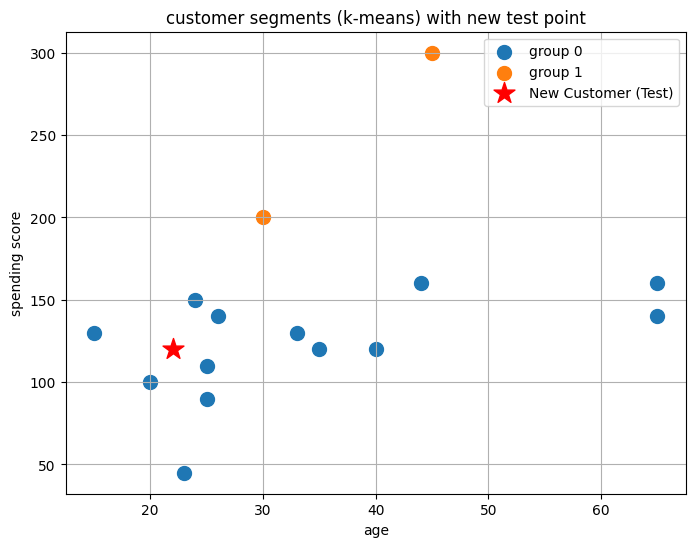

    age  spending  group
0    20       100      0
1    30       200      1
2    25        90      0
3    23        45      0
4    35       120      0
5    33       130      0
6    44       160      0
7    65       140      0
8    25       110      0
9    45       300      1
10   15       130      0
11   24       150      0
12   65       160      0
13   26       140      0
14   40       120      0


In [2]:
# sample data
data={
    'age':[20,30,25,23,35,33,44,65,25,45,15,24,65,26,40],
    'spending':[100,200,90,45,120,130,160,140,110,300,130,150,160,140,120]
}
df=pd.DataFrame(data)

# Fit KMeans model on existing customer data
x=df[['age','spending']]
model=KMeans(n_clusters=2,random_state=42,n_init=10)
df['group']=model.fit_predict(x)

# input another data point to check if the model is working correctly
new_age=int(input("enter age for new customer: "))
new_spending=int(input("enter spending score for new customer: "))

# predict group for the new customer data point
new_data=pd.DataFrame([[new_age, new_spending]], columns=['age', 'spending'])
predicted_grp=model.predict(new_data)[0]
print(f"\nThe new customer (Age: {new_age}, Spending: {new_spending}) is in Group {predicted_grp}\n")

# plot the clusters and show the new data point to visually verify
plt.figure(figsize=(8,6)) 
for grp in df['group'].unique():
    group_data=df[df['group']==grp]
    plt.scatter(group_data['age'],group_data['spending'],label=f'group {grp}', s=100)

# plot the new test point as a red star
plt.scatter(new_age, new_spending, color='red', marker='*', s=250, label='New Customer (Test)')

plt.xlabel('age')
plt.ylabel('spending score')
plt.title("customer segments (k-means) with new test point")
plt.legend()
plt.grid(True)
plt.show()

print(df)